In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.2 MB/s eta 0:00:00


In [3]:
# 필요 라이브러리 임포트
import os
import json
import requests
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import koreanize_matplotlib

import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


In [4]:
# ======================================================
# 1) 경로 설정
# ======================================================
BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
DATA_DIR = os.path.join(BASE_DIR, "Data")
save_dir = os.path.join(BASE_DIR, "preprocessed_EGFRi")  # Cetuximab과 분리 저장
output_dir = os.path.join(BASE_DIR, "outputs", "EGFRi")

os.makedirs(save_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

EXPR_DIR = os.path.join(DATA_DIR, "exprs_homogenized")
MUT_DIR  = os.path.join(DATA_DIR, "SNA_binary")
CNA_DIR  = os.path.join(DATA_DIR, "CNA_binary")
RESP_DIR = os.path.join(DATA_DIR, "response")

print(f"저장 경로: {save_dir}")
print(f"그래프 저장: {output_dir}")

저장 경로: /content/drive/MyDrive/AI Health care 실습파일/MOLI/preprocessed_EGFRi
그래프 저장: /content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi


# Cetuximab vs EGFRi 파일 매핑 차이

| | Cetuximab | EGFRi (Pan-drug) |
|----------|--------|--------|
| Train expr | GDSC_exprs.Cetuximab.eb_with.PDX_... | GDSC_exprs.EGFRi.eb_with.PDX_... |
| Train mut | GDSC_mutations.Cetuximab.tsv | GDSC_mutations.EGFRi.tsv |
| Train cna | GDSC_CNA.Cetuximab | GDSC_CNA.EGFRi |
| Train resp | GDSC_response.Cetuximab.tsv | GDSC_response.EGFRi.tsv |
| Val PDX (expr/mut/cna) | PDX_(expr/mut/cna).Cetuximab.eb_with.GDSC_... | PDX_exprs.EGFRi.eb_with.GDSC_... |
| Val PDX resp (⚠️ 파일명 다름) | PDX_response.multi-OMICS.Cetuximab.tsv | PDX_response.EGFRi.tsv |
| Val TCGA | TCGA_*.Cetuximab | TCGA_*.EGFRi |

===================================================================

In [5]:
# ======================================================
# 2) 데이터 로딩
# ======================================================

# 2-1) Train (GDSC)
train_expr = pd.read_csv(os.path.join(EXPR_DIR,
    "GDSC_exprs.EGFRi.eb_with.PDX_exprs.EGFRi.tsv"), sep="\t", index_col=0, decimal=',')
train_mut  = pd.read_csv(os.path.join(MUT_DIR,
    "GDSC_mutations.EGFRi.tsv"), sep="\t", index_col=0)
train_cna  = pd.read_csv(os.path.join(CNA_DIR,
    "GDSC_CNA.EGFRi.tsv"), sep="\t", index_col=0)
train_resp = pd.read_csv(os.path.join(RESP_DIR,
    "GDSC_response.EGFRi.tsv"), sep="\t", index_col=0)

# 2-2) Validation PDX
val_expr = pd.read_csv(os.path.join(EXPR_DIR,
    "PDX_exprs.EGFRi.eb_with.GDSC_exprs.EGFRi.tsv"), sep="\t", index_col=0, decimal=',')
val_mut  = pd.read_csv(os.path.join(MUT_DIR,
    "PDX_mutations.EGFRi.tsv"), sep="\t", index_col=0)
val_cna  = pd.read_csv(os.path.join(CNA_DIR,
    "PDX_CNA.EGFRi.tsv"), sep="\t", index_col=0)
val_resp = pd.read_csv(os.path.join(RESP_DIR,
    "PDX_response.EGFRi.tsv"), sep="\t", index_col=0)

# 2-3) Validation TCGA
TCGA_expr = pd.read_csv(os.path.join(EXPR_DIR,
    "TCGA_exprs.EGFRi.eb_with.GDSC_exprs.EGFRi.tsv"), sep="\t", index_col=0, decimal=',')
TCGA_mut  = pd.read_csv(os.path.join(MUT_DIR,
    "TCGA_mutations.EGFRi.tsv"), sep="\t", index_col=0)
TCGA_cna  = pd.read_csv(os.path.join(CNA_DIR,
    "TCGA_CNA.EGFRi.tsv"), sep="\t", index_col=0)
TCGA_resp = pd.read_csv(os.path.join(RESP_DIR,
    "TCGA_response.EGFRi.tsv"), sep="\t", index_col=0)

print("=== TRAIN (GDSC) ===")
print(f"  Expression : {train_expr.shape}")
print(f"  Mutation   : {train_mut.shape}")
print(f"  CNA        : {train_cna.shape}")
print(f"  Response   : {train_resp.shape}")

print("\n=== VAL (PDX) ===")
print(f"  Expression : {val_expr.shape}")
print(f"  Mutation   : {val_mut.shape}")
print(f"  CNA        : {val_cna.shape}")
print(f"  Response   : {val_resp.shape}")

print("\n=== VAL (TCGA) ===")
print(f"  Expression : {TCGA_expr.shape}")
print(f"  Mutation   : {TCGA_mut.shape}")
print(f"  CNA        : {TCGA_cna.shape}")
print(f"  Response   : {TCGA_resp.shape}")

=== TRAIN (GDSC) ===
  Expression : (18232, 940)
  Mutation   : (18421, 940)
  CNA        : (24452, 940)
  Response   : (3258, 6)

=== VAL (PDX) ===
  Expression : (18232, 61)
  Mutation   : (15061, 61)
  CNA        : (23271, 61)
  Response   : (81, 15)

=== VAL (TCGA) ===
  Expression : (18216, 15)
  Mutation   : (15050, 15)
  CNA        : (36019, 15)
  Response   : (15, 8)


In [6]:
display(train_expr.head())

,683665,684052,684055,684057,684059,684062,684072,684681,687452,687455,...,1240161,1240199,1287381,1290797,1290813,1290907,1298168,1298476,1659818,1659819
ENTREZID,,,,,,,,,,,,,,,,,,,,,
1,3.584404,4.047325,5.435728,4.721084,4.518960,4.155834,5.304522,3.572692,2.667973,3.125113,...,3.458138,4.669313,2.922102,3.438009,2.676392,3.097144,2.827976,3.600720,2.481326,5.214805
2,3.460668,3.135898,3.305544,6.576387,4.860488,3.214345,3.255805,6.252232,2.971980,3.220765,...,3.109782,3.160323,3.181897,3.064881,3.201312,3.302669,2.888756,3.233879,3.543534,3.374255
9,7.426252,5.364285,6.282655,5.521902,5.686492,6.216194,4.812219,4.406423,5.898495,7.108910,...,6.434687,7.274043,4.103809,4.699151,7.135825,5.620231,6.138411,7.835216,7.341178,7.876941
10,2.908837,3.046480,2.996855,3.099219,2.985088,3.183457,3.066252,3.106590,2.816360,3.098869,...,2.819118,3.655026,3.126600,2.990855,2.911198,4.412166,2.932302,3.217894,3.207948,3.029962
12,2.993574,2.837021,2.799071,3.028259,2.963831,2.746134,3.175212,3.780286,6.252113,2.964389,...,7.471226,2.810123,5.413445,2.688027,2.821725,3.094278,2.821492,3.622099,5.746754,2.891456


In [7]:
# ======================================================
# 3) Response 구조 확인
# ======================================================
print("=== Train Response ===")
print(f"컬럼: {train_resp.columns.tolist()}")
print(train_resp.head(3))
print(f"\n값 분포:\n{train_resp['response'].value_counts()}")

print("\n=== Val PDX Response ===")
print(f"컬럼: {val_resp.columns.tolist()}")
print(val_resp.head(3))
print(f"\n값 분포:\n{val_resp['response'].value_counts()}")

print("\n=== TCGA Response ===")
print(f"컬럼: {TCGA_resp.columns.tolist()}")
print(TCGA_resp.head(3))
print(f"\n값 분포:\n{TCGA_resp['response'].value_counts()}")

=== Train Response ===
컬럼: ['response', 'logIC50', 'drug', 'exprs', 'CNA', 'mutations']
            response   logIC50       drug  exprs  CNA  mutations
sample_name                                                     
683665             R  6.294447  Cetuximab      1    1          1
683665             R  2.436586  Erlotinib      1    1          1
683665             R  2.684181  Lapatinib      1    1          1

값 분포:
response
R    2747
S     511
Name: count, dtype: int64

=== Val PDX Response ===
컬럼: ['drug', 'response', 'ResponseCategory', 'Treatment', 'Treatment target', 'Treatment type', 'BestResponse', 'Day_BestResponse', 'BestAvgResponse', 'Day_BestAvgResponse', 'TimeToDouble', 'Day_Last', 'exprs', 'CNA', 'mutations']
                  drug response ResponseCategory  Treatment Treatment target  \
sample_name                                                                    
X-1027       Cetuximab        R               PD  cetuximab             EGFR   
X-1119       Cetuximab      

In [8]:
# response 파일에서 중복 확인
print(f"전체 response 행수: {len(train_resp)}")
print(f"unique 세포주 수: {train_resp.index.nunique()}")
print(f"\n약물별 샘플 수:")
print(train_resp['drug'].value_counts())

전체 response 행수: 3258
unique 세포주 수: 940

약물별 샘플 수:
drug
Cetuximab    856
Afatinib     828
Gefitinib    825
Lapatinib    387
Erlotinib    362
Name: count, dtype: int64


In [9]:
# ======================================================
# 4) 3,258행 기준으로 매핑
# ======================================================

# 4-1) train_labels: index = 세포주ID (중복 있음), 값 = R/S
train_resp.index = train_resp.index.astype(str)
train_labels = train_resp['response'].map({'R': 0, 'S': 1})

# 4-2) omics에 있는 세포주만 필터링 (중복 유지)
valid_mask = train_labels.index.isin(train_expr.columns) & \
             train_labels.index.isin(train_mut.columns)  & \
             train_labels.index.isin(train_cna.columns)

train_labels_filtered = train_labels[valid_mask]
print(f"전체 response: {len(train_labels)}")
print(f"omics 매핑 가능: {len(train_labels_filtered)}")
print(f"약물별 분포:\n{train_resp[valid_mask]['drug'].value_counts()}")
print(f"\n라벨 분포: {train_labels_filtered.value_counts().to_dict()}")

전체 response: 3258
omics 매핑 가능: 3258
약물별 분포:
drug
Cetuximab    856
Afatinib     828
Gefitinib    825
Lapatinib    387
Erlotinib    362
Name: count, dtype: int64

라벨 분포: {0: 2747, 1: 511}


In [10]:
# ======================================================
# 5) 3,258행에 맞게 omics 행렬 구성
# ======================================================

# 5-1) 공통 유전자 (Train ∩ PDX)
common_expr_genes = sorted(set(train_expr.index) & set(val_expr.index))
common_mut_genes  = sorted(set(train_mut.index)  & set(val_mut.index))
common_cna_genes  = sorted(set(train_cna.index)  & set(val_cna.index))

# Train 유전자 중복 검사 및 제거
print("[Train 중복 유전자 검사]")
for name, df in [('train_expr', train_expr),
                  ('train_mut',  train_mut),
                  ('train_cna',  train_cna)]:
    n_dup = df.index.duplicated().sum()
    if n_dup > 0:
        print(f"  ⚠️  {name}: 중복 {n_dup}개 → 제거")
        if   name == 'train_expr': train_expr = train_expr[~train_expr.index.duplicated(keep='first')]
        elif name == 'train_mut':  train_mut  = train_mut[~train_mut.index.duplicated(keep='first')]
        elif name == 'train_cna':  train_cna  = train_cna[~train_cna.index.duplicated(keep='first')]
    else:
        print(f"  ✅  {name}: 중복 없음")

# 5-2) 세포주 ID 리스트 (중복 포함, 3,258개)
cell_ids = train_labels_filtered.index.tolist()

# 5-3) Train omics 행렬 구성
X_train_expr = train_expr.loc[common_expr_genes, cell_ids].T
X_train_mut  = train_mut.loc[common_mut_genes,   cell_ids].T
X_train_cna  = train_cna.loc[common_cna_genes,   cell_ids].T
y_train = train_labels_filtered

print(f"\nshape 확인 (행=3258, 열=유전자):")
print(f"  X_train_expr : {X_train_expr.shape}")
print(f"  X_train_mut  : {X_train_mut.shape}")
print(f"  X_train_cna  : {X_train_cna.shape}")
print(f"  y_train      : {y_train.shape} | {y_train.value_counts().to_dict()}")

[Train 중복 유전자 검사]
  ✅  train_expr: 중복 없음
  ✅  train_mut: 중복 없음
  ✅  train_cna: 중복 없음

shape 확인 (행=3258, 열=유전자):
  X_train_expr : (3258, 18232)
  X_train_mut  : (3258, 14455)
  X_train_cna  : (3258, 20503)
  y_train      : (3258,) | {0: 2747, 1: 511}


In [11]:
# scaler를 먼저 fit → mean_ 확보 후 패딩
# Expression 정규화: Train에 fit
scaler = StandardScaler()
X_train_expr_scaled = scaler.fit_transform(X_train_expr)

# scaler.mean_: 유전자별 Train 평균값 (Mean Imputation에 사용)
expr_gene_means = pd.Series(scaler.mean_, index=common_expr_genes)

# 5-4) PDX 처리 (Drug Embedding 도입으로 중복 포함 81개 전체 사용)
val_resp.index   = val_resp.index.astype(str)
val_labels       = val_resp['response'].map({'R': 0, 'S': 1})
val_valid_mask   = (val_labels.index.isin(val_expr.columns) &
                    val_labels.index.isin(val_mut.columns)  &
                    val_labels.index.isin(val_cna.columns))
val_labels_filtered = val_labels[val_valid_mask]
val_resp_valid      = val_resp[val_valid_mask]
val_cell_ids        = val_labels_filtered.index.tolist()

print(f"\n✅ Val PDX 전체 사용: {len(val_labels_filtered)}개 (중복 포함)")
print(f"   라벨 분포: {val_labels_filtered.value_counts().to_dict()}")
print(f"   약물 분포:\n{val_resp_valid['drug'].value_counts()}")


✅ Val PDX 전체 사용: 81개 (중복 포함)
   라벨 분포: {0: 73, 1: 8}
   약물 분포:
drug
Cetuximab    60
Erlotinib    21
Name: count, dtype: int64


In [12]:
# 패딩 함수 정의
def pad_binary_to_reference(df, reference_genes, sample_cols):
    """
    Mutation / CNA 용 (이진 데이터)
    없는 유전자 → 0 패딩 (0 = 변이 없음 / 정상 복제수)
    """
    df = df[~df.index.duplicated(keep='first')]
    df_sub = df.loc[df.index.isin(reference_genes), sample_cols]
    missing = sorted(set(reference_genes) - set(df_sub.index))
    if missing:
        df_sub = pd.concat([df_sub,
                            pd.DataFrame(0, index=missing, columns=sample_cols)])
    return df_sub.loc[reference_genes]


def pad_expr_to_reference(df, reference_genes, sample_cols, gene_means):
    """
    Expression 용 (연속 데이터)
    없는 유전자 → Train 유전자별 평균으로 패딩 (Mean Imputation)
    StandardScaler 적용 후 해당 위치가 정확히 0이 됨
    """
    df = df[~df.index.duplicated(keep='first')]
    df_sub = df.loc[df.index.isin(reference_genes), sample_cols].copy()
    missing = sorted(set(reference_genes) - set(df_sub.index))
    if missing:
        fill_vals = gene_means.reindex(missing).fillna(0).values  # (n_missing,)
        fill_df = pd.DataFrame(
            np.tile(fill_vals.reshape(-1, 1), (1, len(sample_cols))),
            index=missing, columns=sample_cols
        )
        df_sub = pd.concat([df_sub, fill_df])
    return df_sub.loc[reference_genes]

In [13]:
# 5-5) PDX 행렬 구성
# common_expr_genes = Train ∩ PDX이므로 PDX expr에 누락 유전자 없음
# (패딩은 실질적으로 발생하지 않지만, 함수 통일성을 위해 적용)
X_val_expr_raw = pad_expr_to_reference(
    val_expr, common_expr_genes, val_cell_ids, expr_gene_means).T
X_val_mut      = pad_binary_to_reference(
    val_mut, common_mut_genes, val_cell_ids).T
X_val_cna      = pad_binary_to_reference(
    val_cna, common_cna_genes, val_cell_ids).T
y_val = val_labels_filtered

print(f"\n  X_val_expr : {X_val_expr_raw.shape}  ← (81, 유전자수)")
print(f"  y_val      : {y_val.shape} | {y_val.value_counts().to_dict()}")

# 5-6) 정규화
X_val_expr_scaled = scaler.transform(X_val_expr_raw)

# 패딩 위치 확인 (Mean Imputation 검증)
n_padded_val = len(set(common_expr_genes) - set(val_expr.index))
print(f"\nPDX expr 누락 유전자: {n_padded_val}개 → Train 평균으로 패딩")
if n_padded_val > 0:
    # 패딩된 유전자는 스케일링 후 정확히 0이어야 함
    padded_genes = sorted(set(common_expr_genes) - set(val_expr.index))
    padded_idx   = [common_expr_genes.index(g) for g in padded_genes]
    padded_vals  = X_val_expr_scaled[:, padded_idx]
    print(f"패딩 위치 스케일링 후 절댓값 평균: {np.abs(padded_vals).mean():.6f} (기대: 0)")

# 5-7) numpy 변환
X_train_mut_np = X_train_mut.values.astype(np.float32)
X_train_cna_np = X_train_cna.values.astype(np.float32)
X_val_mut_np   = X_val_mut.values.astype(np.float32)
X_val_cna_np   = X_val_cna.values.astype(np.float32)
y_train_np     = y_train.values.astype(np.float32)
y_val_np       = y_val.values.astype(np.float32)

print(f"\n✅ 정규화 완료")
print(f"  mean: {X_train_expr_scaled.mean():.4f}")
print(f"  std : {X_train_expr_scaled.std():.4f}")


  X_val_expr : (81, 18232)  ← (81, 유전자수)
  y_val      : (81,) | {0: 73, 1: 8}

PDX expr 누락 유전자: 0개 → Train 평균으로 패딩

✅ 정규화 완료
  mean: -0.0000
  std : 1.0000


In [14]:
# ======================================================
# 6) TCGA 전처리 (Mean Imputation 적용)
# ======================================================

# 6-1) CNA 중복 제거
print(f"TCGA_cna index 중복: {TCGA_cna.index.duplicated().sum()}개")
TCGA_cna = TCGA_cna[~TCGA_cna.index.duplicated(keep='first')]
print(f"중복 제거 후 TCGA_cna: {TCGA_cna.shape}")

# 6-2) 유효 샘플 확인
valid_samples = [sid for sid in TCGA_resp.index
                 if sid in TCGA_expr.columns
                 and sid in TCGA_mut.columns
                 and sid in TCGA_cna.columns]
print(f"TCGA 유효 샘플: {len(valid_samples)}개")

# 6-3) 행렬 구성
# Expression: Mean Imputation (TCGA는 18216유전자 → 16개 누락)
# Mutation/CNA: 0 패딩 (이진 데이터)
X_tcga_expr_raw = pad_expr_to_reference(
    TCGA_expr, common_expr_genes, valid_samples, expr_gene_means).T
X_tcga_mut = pad_binary_to_reference(
    TCGA_mut, common_mut_genes, valid_samples).T
X_tcga_cna = pad_binary_to_reference(
    TCGA_cna, common_cna_genes, valid_samples).T

TCGA_labels = TCGA_resp['response'].map({'R': 0, 'S': 1})
y_tcga      = TCGA_labels[valid_samples]

# 6-4) 패딩 검증
n_padded_tcga = len(set(common_expr_genes) - set(TCGA_expr.index))
print(f"\n  TCGA expr 누락 유전자: {n_padded_tcga}개 → Train 평균으로 패딩")

X_tcga_expr_scaled = scaler.transform(X_tcga_expr_raw)

if n_padded_tcga > 0:
    padded_genes = sorted(set(common_expr_genes) - set(TCGA_expr.index))
    padded_idx   = [common_expr_genes.index(g) for g in padded_genes]
    padded_vals  = X_tcga_expr_scaled[:, padded_idx]
    print(f"  패딩 위치 스케일링 후 절댓값 평균: {np.abs(padded_vals).mean():.6f} (기대: 0)")

X_tcga_mut_np = X_tcga_mut.values.astype(np.float32)
X_tcga_cna_np = X_tcga_cna.values.astype(np.float32)
y_tcga_np     = y_tcga.values.astype(np.float32)

print(f"\n패딩 후 shape:")
print(f"  X_tcga_expr : {X_tcga_expr_scaled.shape}")
print(f"  X_tcga_mut  : {X_tcga_mut_np.shape}")
print(f"  X_tcga_cna  : {X_tcga_cna_np.shape}")
print(f"  y           : {y_tcga_np.shape} | S:{int((y_tcga_np==1).sum())} R:{int((y_tcga_np==0).sum())}")

TCGA_cna index 중복: 47개
중복 제거 후 TCGA_cna: (35972, 15)
TCGA 유효 샘플: 15개

  TCGA expr 누락 유전자: 118개 → Train 평균으로 패딩
  패딩 위치 스케일링 후 절댓값 평균: 0.000000 (기대: 0)

패딩 후 shape:
  X_tcga_expr : (15, 18232)
  X_tcga_mut  : (15, 14455)
  X_tcga_cna  : (15, 20503)
  y           : (15,) | S:7 R:8


In [15]:
# ======================================================
# 7) 데이터 품질 검사
# ======================================================
print("=" * 50)
print("데이터 품질 검사")
print("=" * 50)

# 7-1) 결측치
print("\n[결측치]")
for name, arr in [
    ("X_train_expr", X_train_expr_scaled), ("X_train_mut", X_train_mut_np),
    ("X_train_cna",  X_train_cna_np),      ("y_train",     y_train_np),
    ("X_val_expr",   X_val_expr_scaled),   ("X_val_mut",   X_val_mut_np),
    ("X_val_cna",    X_val_cna_np),        ("y_val",       y_val_np),
    ("X_tcga_expr",  X_tcga_expr_scaled),  ("X_tcga_mut",  X_tcga_mut_np),
    ("X_tcga_cna",   X_tcga_cna_np),       ("y_tcga",      y_tcga_np),
]:
    print(f"  {name:15s} NaN: {np.isnan(arr).sum()}")


# 7-2) Data Leakage 검사 (강화 버전)
print("\n[Data Leakage 검사]")

train_common = sorted(
    set(train_labels.index) & set(train_expr.columns)
    & set(train_mut.columns) & set(train_cna.columns)
)
val_common = sorted(
    set(val_labels.index) & set(val_expr.columns)
    & set(val_mut.columns) & set(val_cna.columns)
)

# (1) ID 기반 검사 (기본)
overlap_pdx  = set(train_common) & set(val_common)
overlap_tcga = set(train_common) & set(valid_samples)
print(f"  [ID 기반] Train-PDX  겹치는 샘플: {len(overlap_pdx)}개  "
      + ("✅ 없음" if not overlap_pdx  else f"⚠️ {overlap_pdx}"))
print(f"  [ID 기반] Train-TCGA 겹치는 샘플: {len(overlap_tcga)}개 "
      + ("✅ 없음" if not overlap_tcga else f"⚠️ {overlap_tcga}"))
print(f"  ※ 단, Train(숫자ID)과 PDX(X-xxxx)/TCGA(TCGA-xx)는 네이밍 규칙이 달라")
print(f"     ID 비교만으로는 충분하지 않음 → 발현 프로파일 상관관계로 추가 검증")

# (2) 발현 프로파일 상관관계 기반 검사
# Train 샘플별 평균 발현 벡터 (샘플 수가 많으므로 평균 사용)
train_expr_mean = X_train_expr_scaled.mean(axis=0)  # (n_genes,)

# PDX 각 샘플과 Train 전체 간 최대 Pearson 상관계수
print(f"\n  [상관관계 기반] PDX ↔ Train 발현 프로파일 유사도 검사")
from numpy.linalg import norm

def cosine_sim_batch(val_mat, train_mat, top_k=1):
    """val 각 샘플과 train 전체 간 코사인 유사도 최댓값 반환"""
    val_norm   = val_mat   / (norm(val_mat,   axis=1, keepdims=True) + 1e-8)
    train_norm = train_mat / (norm(train_mat, axis=1, keepdims=True) + 1e-8)
    sims = val_norm @ train_norm.T  # (n_val, n_train)
    return sims.max(axis=1)         # 각 val 샘플의 최대 유사도

pdx_max_sim  = cosine_sim_batch(X_val_expr_scaled,   X_train_expr_scaled)
tcga_max_sim = cosine_sim_batch(X_tcga_expr_scaled,  X_train_expr_scaled)

LEAKAGE_THRESHOLD = 0.99
pdx_suspicious  = np.where(pdx_max_sim  > LEAKAGE_THRESHOLD)[0]
tcga_suspicious = np.where(tcga_max_sim > LEAKAGE_THRESHOLD)[0]

print(f"  PDX  최대 유사도: {pdx_max_sim.max():.4f}  "
      + (f"⚠️ {len(pdx_suspicious)}개 의심 샘플" if len(pdx_suspicious) else "✅ 정상"))
print(f"  TCGA 최대 유사도: {tcga_max_sim.max():.4f}  "
      + (f"⚠️ {len(tcga_suspicious)}개 의심 샘플" if len(tcga_suspicious) else "✅ 정상"))
print(f"  (임계값: cosine similarity > {LEAKAGE_THRESHOLD})")

# 7-3) 무분산 유전자
print(f"\n[무분산 유전자]")
zero_var_expr = (X_train_expr_scaled.std(axis=0) == 0).sum()
zero_var_mut  = (X_train_mut_np.std(axis=0) == 0).sum()
zero_var_cna  = (X_train_cna_np.std(axis=0) == 0).sum()
print(f"  Expression: {zero_var_expr}개")
print(f"  Mutation  : {zero_var_mut}개")
print(f"  CNA       : {zero_var_cna}개")
print("\n✅ 품질 검사 완료")

데이터 품질 검사

[결측치]
  X_train_expr    NaN: 0
  X_train_mut     NaN: 0
  X_train_cna     NaN: 0
  y_train         NaN: 0
  X_val_expr      NaN: 0
  X_val_mut       NaN: 0
  X_val_cna       NaN: 0
  y_val           NaN: 0
  X_tcga_expr     NaN: 0
  X_tcga_mut      NaN: 0
  X_tcga_cna      NaN: 0
  y_tcga          NaN: 0

[Data Leakage 검사]
  [ID 기반] Train-PDX  겹치는 샘플: 0개  ✅ 없음
  [ID 기반] Train-TCGA 겹치는 샘플: 0개 ✅ 없음
  ※ 단, Train(숫자ID)과 PDX(X-xxxx)/TCGA(TCGA-xx)는 네이밍 규칙이 달라
     ID 비교만으로는 충분하지 않음 → 발현 프로파일 상관관계로 추가 검증

  [상관관계 기반] PDX ↔ Train 발현 프로파일 유사도 검사
  PDX  최대 유사도: 0.4181  ✅ 정상
  TCGA 최대 유사도: 0.3429  ✅ 정상
  (임계값: cosine similarity > 0.99)

[무분산 유전자]
  Expression: 0개
  Mutation  : 8개
  CNA       : 0개

✅ 품질 검사 완료


In [16]:
# 7-4) 무분산 유전자 제거
if X_train_mut_np.shape[1] != (X_train_mut_np.shape[1] - int((X_train_mut_np.std(axis=0) == 0).sum())):
    zero_var_mask = X_train_mut_np.std(axis=0) != 0
    X_train_mut_np = X_train_mut_np[:, zero_var_mask]
    X_val_mut_np   = X_val_mut_np[:,   zero_var_mask]
    X_tcga_mut_np  = X_tcga_mut_np[:,  zero_var_mask]
    print(f"Mutation 유전자 제거 후: {X_train_mut_np.shape[1]}개")
else:
    zero_var_mask = np.ones(X_train_mut_np.shape[1], dtype=bool)

Mutation 유전자 제거 후: 14447개


## 시각화

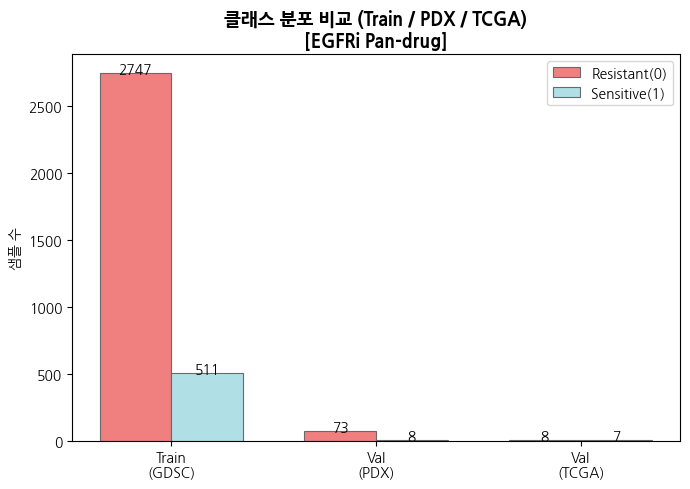

In [17]:
# ======================================================
# 8)EDA 시각화
# ======================================================

# 8-1) 클래스 분포 비교
fig, ax = plt.subplots(figsize=(7, 5))
datasets = {'Train\n(GDSC)': y_train_np,
            'Val\n(PDX)':    y_val_np,
            'Val\n(TCGA)':   y_tcga_np}
x = np.arange(len(datasets))
width = 0.35
r_counts = [int((v==0).sum()) for v in datasets.values()]
s_counts = [int((v==1).sum()) for v in datasets.values()]
bars_r = ax.bar(x - width/2, r_counts, width, label='Resistant(0)',
                color='#F08080', edgecolor='dimgray', linewidth=0.8)
bars_s = ax.bar(x + width/2, s_counts, width, label='Sensitive(1)',
                color='#B0E0E6', edgecolor='dimgray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(datasets.keys())
ax.set_title('클래스 분포 비교 (Train / PDX / TCGA)\n[EGFRi Pan-drug]',
             fontsize=13, fontweight='bold')
ax.set_ylabel('샘플 수')
ax.legend()
for bar, cnt in zip(list(bars_r)+list(bars_s), r_counts+s_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(cnt), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_01_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

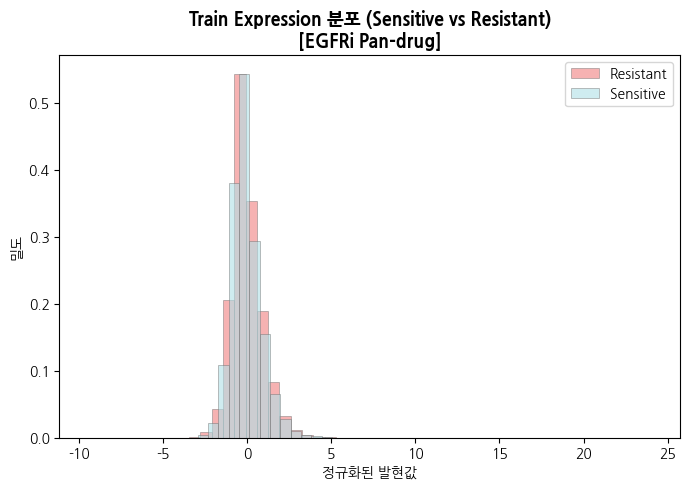

In [18]:
# 8-2) Train Expression 분포
fig, ax = plt.subplots(figsize=(7, 5))
sample_idx = np.random.choice(X_train_expr_scaled.shape[1], 500, replace=False)
r_vals = X_train_expr_scaled[y_train_np == 0][:, sample_idx].flatten()
s_vals = X_train_expr_scaled[y_train_np == 1][:, sample_idx].flatten()
ax.hist(r_vals, bins=50, alpha=0.6, color='#F08080', label='Resistant',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(s_vals, bins=50, alpha=0.6, color='#B0E0E6', label='Sensitive',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.set_title('Train Expression 분포 (Sensitive vs Resistant)\n[EGFRi Pan-drug]',
             fontsize=13, fontweight='bold')
ax.set_xlabel('정규화된 발현값')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_02_expression_dist.png', dpi=150, bbox_inches='tight')
plt.show()

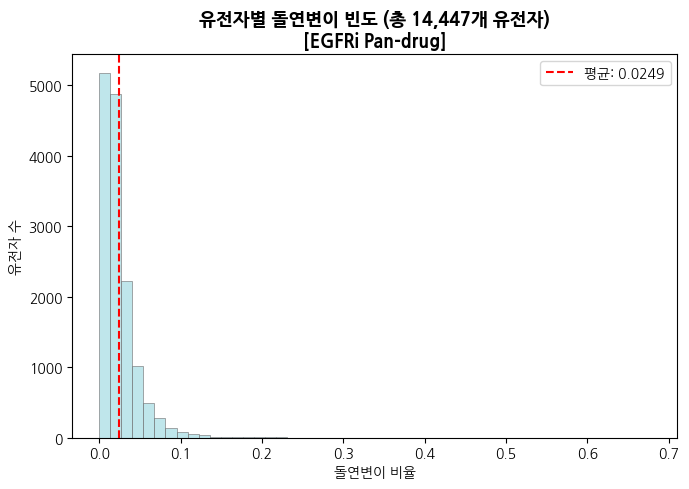

In [19]:
# 8-3) 유전자별 돌연변이 빈도
fig, ax = plt.subplots(figsize=(7, 5))
mut_rate = X_train_mut_np.mean(axis=0)
ax.hist(mut_rate, bins=50, color='#B0E0E6', alpha=0.8,
        edgecolor='dimgray', linewidth=0.5)
ax.axvline(mut_rate.mean(), color='red', linestyle='--',
           label=f'평균: {mut_rate.mean():.4f}')
ax.set_title(f'유전자별 돌연변이 빈도 (총 {len(mut_rate):,}개 유전자)\n[EGFRi Pan-drug]',
             fontsize=13, fontweight='bold')
ax.set_xlabel('돌연변이 비율')
ax.set_ylabel('유전자 수')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_03_mutation_freq.png', dpi=150, bbox_inches='tight')
plt.show()

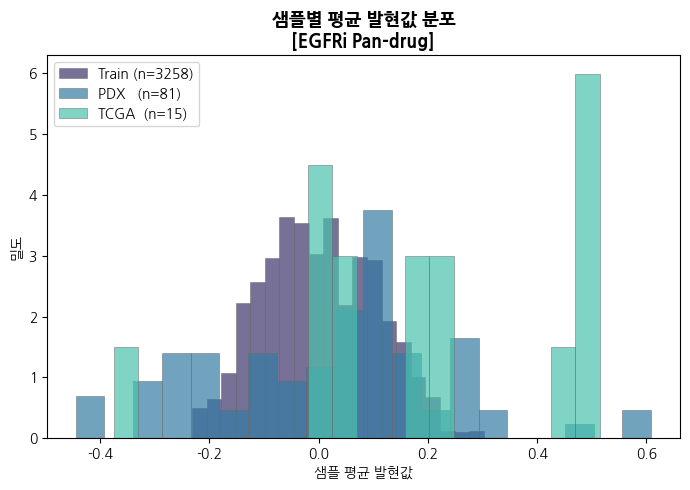

In [20]:
# 8-4) 샘플별 평균 발현값 분포 비교
import seaborn as sns
mako = sns.color_palette("mako", 3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(X_train_expr_scaled.mean(axis=1), bins=20, alpha=0.7,
        color=mako[0], label=f'Train (n={len(y_train_np)})',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(X_val_expr_scaled.mean(axis=1),   bins=20, alpha=0.7,
        color=mako[1], label=f'PDX   (n={len(y_val_np)})',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(X_tcga_expr_scaled.mean(axis=1),  bins=20, alpha=0.7,
        color=mako[2], label=f'TCGA  (n={len(y_tcga_np)})',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.set_title('샘플별 평균 발현값 분포\n[EGFRi Pan-drug]',
             fontsize=13, fontweight='bold')
ax.set_xlabel('샘플 평균 발현값')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_04_expr_compare.png', dpi=150, bbox_inches='tight')
plt.show()

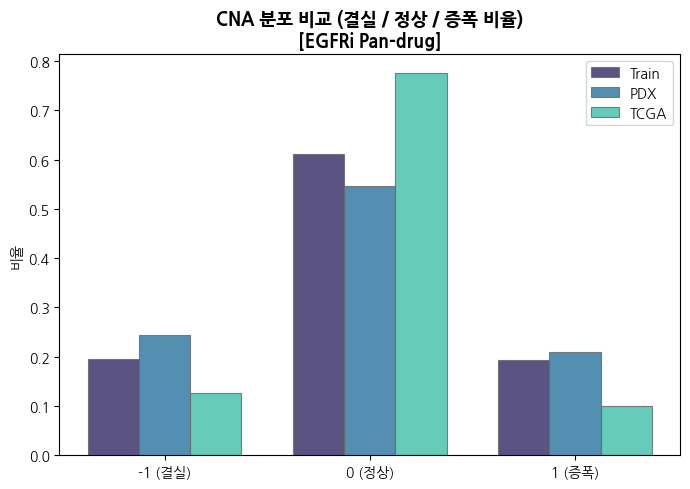

In [21]:
# 8-5) CNA 분포 비교
fig, ax = plt.subplots(figsize=(7, 5))
cna_labels = ['-1 (결실)', '0 (정상)', '1 (증폭)']
train_cna_dist = [(X_train_cna_np == v).mean() for v in [-1, 0, 1]]
val_cna_dist   = [(X_val_cna_np   == v).mean() for v in [-1, 0, 1]]
tcga_cna_dist  = [(X_tcga_cna_np  == v).mean() for v in [-1, 0, 1]]
x = np.arange(3)
width = 0.25
ax.bar(x - width, train_cna_dist, width, label='Train',
       color=mako[0], alpha=0.85, edgecolor='dimgray', linewidth=0.8)
ax.bar(x,          val_cna_dist,  width, label='PDX',
       color=mako[1], alpha=0.85, edgecolor='dimgray', linewidth=0.8)
ax.bar(x + width,  tcga_cna_dist, width, label='TCGA',
       color=mako[2], alpha=0.85, edgecolor='dimgray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cna_labels)
ax.set_title('CNA 분포 비교 (결실 / 정상 / 증폭 비율)\n[EGFRi Pan-drug]',
             fontsize=13, fontweight='bold')
ax.set_ylabel('비율')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_05_cna_compare.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# 8-6) 데이터셋 요약 텍스트
print("=" * 50)
print("📌 EGFRi Pan-drug 데이터셋 요약")
print("=" * 50)
print(f"포함 약물: Afatinib / Cetuximab / Erlotinib / Gefitinib / Lapatinib")
print(f"\nTrain (GDSC) : {len(y_train_np)}샘플  (논문: 3,258)")
print(f"  R:{int((y_train_np==0).sum())} / S:{int((y_train_np==1).sum())}"
      f"  (불균형 비율 1:{int((y_train_np==0).sum())//max(int((y_train_np==1).sum()),1)})")
print(f"\nVal   (PDX)  : {len(y_val_np)}샘플")
print(f"  R:{int((y_val_np==0).sum())} / S:{int((y_val_np==1).sum())}")
print(f"\nVal   (TCGA) : {len(y_tcga_np)}샘플  ← ⭐ 추가 검증")
print(f"  R:{int((y_tcga_np==0).sum())} / S:{int((y_tcga_np==1).sum())}")
print(f"\n입력 차원")
print(f"  Expression : {X_train_expr_scaled.shape[1]:,}")
print(f"  Mutation   : {X_train_mut_np.shape[1]:,}")
print(f"  CNA        : {X_train_cna_np.shape[1]:,}")
print(f"\n돌연변이 평균 빈도: {mut_rate.mean():.4f} ({mut_rate.mean()*100:.2f}%)")
print("=" * 50)

📌 EGFRi Pan-drug 데이터셋 요약
포함 약물: Afatinib / Cetuximab / Erlotinib / Gefitinib / Lapatinib

Train (GDSC) : 3258샘플  (논문: 3,258)
  R:2747 / S:511  (불균형 비율 1:5)

Val   (PDX)  : 81샘플
  R:73 / S:8

Val   (TCGA) : 15샘플  ← ⭐ 추가 검증
  R:8 / S:7

입력 차원
  Expression : 18,232
  Mutation   : 14,447
  CNA        : 20,503

돌연변이 평균 빈도: 0.0249 (2.49%)


In [23]:
# ======================================================
# Drug ID 인코딩 및 저장
# ======================================================

DRUG_TO_IDX = {
    'Cetuximab' : 0,
    'Afatinib'  : 1,
    'Erlotinib' : 2,
    'Gefitinib' : 3,
    'Lapatinib' : 4
}

# Train drug_id (3258개, 중복 포함)
drug_id_train = np.array([
    DRUG_TO_IDX[d] for d in train_resp[valid_mask]['drug']
]).astype(np.int64)

# Val PDX drug_id (81개, 중복 포함)
drug_id_val = np.array([
    DRUG_TO_IDX[d] for d in val_resp_valid['drug']
]).astype(np.int64)

# TCGA drug_id (15개)
drug_id_tcga = np.array([
    DRUG_TO_IDX[d] for d in TCGA_resp.loc[valid_samples, 'drug']
]).astype(np.int64)

print("✅ Drug ID 인코딩 완료")
print(f"  Train : {drug_id_train.shape} | 분포: {dict(zip(*np.unique(drug_id_train, return_counts=True)))}")
print(f"  Val   : {drug_id_val.shape}   | 분포: {dict(zip(*np.unique(drug_id_val,   return_counts=True)))}")
print(f"  TCGA  : {drug_id_tcga.shape}   | 분포: {dict(zip(*np.unique(drug_id_tcga,  return_counts=True)))}")
print(f"\n  매핑: {DRUG_TO_IDX}")

✅ Drug ID 인코딩 완료
  Train : (3258,) | 분포: {np.int64(0): np.int64(856), np.int64(1): np.int64(828), np.int64(2): np.int64(362), np.int64(3): np.int64(825), np.int64(4): np.int64(387)}
  Val   : (81,)   | 분포: {np.int64(0): np.int64(60), np.int64(2): np.int64(21)}
  TCGA  : (15,)   | 분포: {np.int64(0): np.int64(10), np.int64(2): np.int64(3), np.int64(3): np.int64(2)}

  매핑: {'Cetuximab': 0, 'Afatinib': 1, 'Erlotinib': 2, 'Gefitinib': 3, 'Lapatinib': 4}


In [24]:
# 결측치 확인
print(f"  drug_id_train NaN: {np.isnan(drug_id_train.astype(float)).sum()}")
print(f"  drug_id_val   NaN: {np.isnan(drug_id_val.astype(float)).sum()}")
print(f"  drug_id_tcga  NaN: {np.isnan(drug_id_tcga.astype(float)).sum()}")

  drug_id_train NaN: 0
  drug_id_val   NaN: 0
  drug_id_tcga  NaN: 0


/tmp/ipykernel_7936/2198932406.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis5    = cm.get_cmap('viridis', 5)


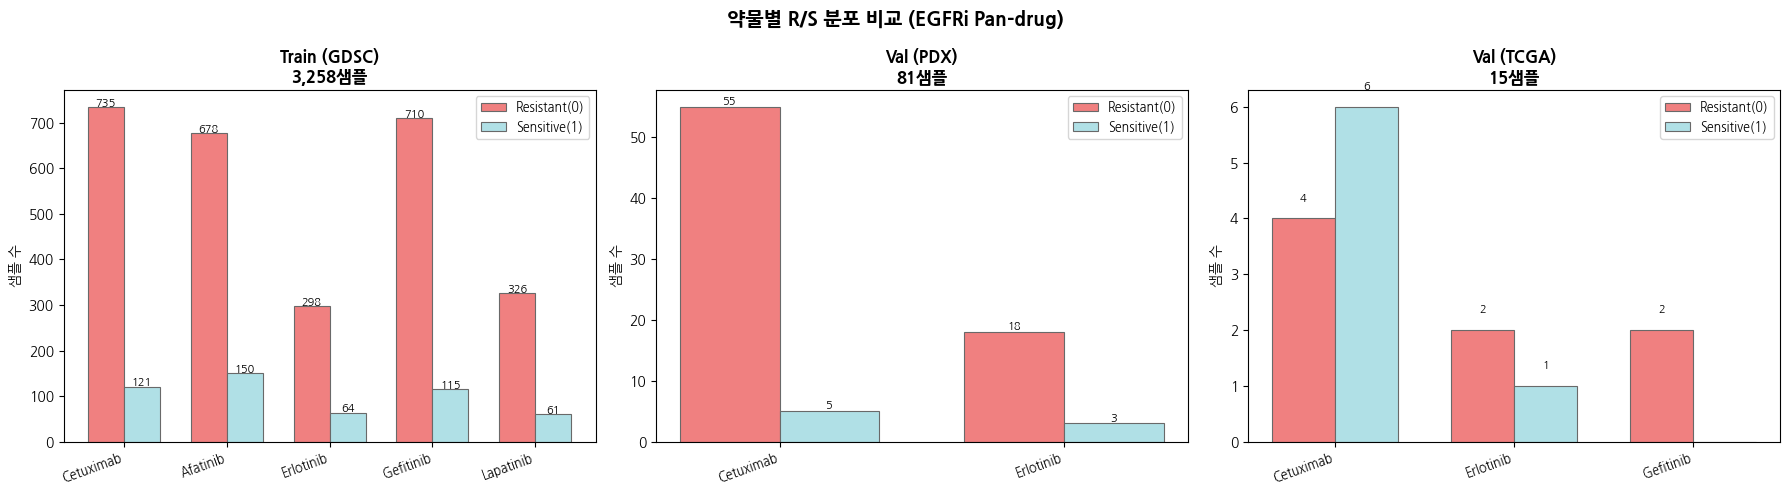

✅ Drug 분포 그래프 저장 완료


In [25]:
# Drug 분포 시각화
IDX_TO_DRUG = {v: k for k, v in DRUG_TO_IDX.items()}
drug_names  = [IDX_TO_DRUG[i] for i in range(5)]
viridis5    = cm.get_cmap('viridis', 5)
colors      = [viridis5(i/4) for i in range(5)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, drug_ids, y) in zip(axes, [
    ('Train (GDSC)\n3,258샘플', drug_id_train, y_train_np),
    ('Val (PDX)\n81샘플',       drug_id_val,   y_val_np),
    ('Val (TCGA)\n15샘플',      drug_id_tcga,  y_tcga_np),
]):
    # 약물별 R/S 분포
    unique_drugs = sorted(set(drug_ids))
    x     = np.arange(len(unique_drugs))
    width = 0.35

    r_counts = [int(((drug_ids == d) & (y == 0)).sum()) for d in unique_drugs]
    s_counts = [int(((drug_ids == d) & (y == 1)).sum()) for d in unique_drugs]
    labels   = [IDX_TO_DRUG[d] for d in unique_drugs]

    bars_r = ax.bar(x - width/2, r_counts, width,
                    label='Resistant(0)', color='#F08080',
                    edgecolor='dimgray', linewidth=0.8)
    bars_s = ax.bar(x + width/2, s_counts, width,
                    label='Sensitive(1)',  color='#B0E0E6',
                    edgecolor='dimgray', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('샘플 수')
    ax.legend(fontsize=9)

    for bar, cnt in zip(list(bars_r) + list(bars_s),
                        r_counts + s_counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    str(cnt), ha='center', fontsize=8)

plt.suptitle('약물별 R/S 분포 비교 (EGFRi Pan-drug)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/eda_drug_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Drug 분포 그래프 저장 완료")

## 저장

In [26]:
# ======================================================
# 9) 저장
# ======================================================

# 9-1) numpy 저장
files = {
    'X_train_expr' : X_train_expr_scaled.astype(np.float32),
    'X_train_mut'  : X_train_mut_np,
    'X_train_cna'  : X_train_cna_np,
    'drug_id_train': drug_id_train,
    'y_train'      : y_train_np,

    'X_val_expr'   : X_val_expr_scaled.astype(np.float32),
    'X_val_mut'    : X_val_mut_np,
    'X_val_cna'    : X_val_cna_np,
    'drug_id_val'  : drug_id_val,
    'y_val'        : y_val_np,

    'X_tcga_expr'  : X_tcga_expr_scaled.astype(np.float32),
    'X_tcga_mut'   : X_tcga_mut_np,
    'X_tcga_cna'   : X_tcga_cna_np,
    'y_tcga'       : y_tcga_np,
    'drug_id_tcga' : drug_id_tcga,

    'zero_var_mask': zero_var_mask,
}
for name, arr in files.items():
    np.save(f"{save_dir}/{name}.npy", arr)

# 9-2) scaler 파라미터를 json으로 저장 (버전 무관)
scaler_params = {
    'mean_': scaler.mean_.tolist(),
    'scale_': scaler.scale_.tolist(),
    'var_': scaler.var_.tolist(),
    'n_features_in_': int(scaler.n_features_in_),
}

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
with open(f'{output_dir}/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

print("✅ scaler_params.json 저장 완료")

# 9-3) meta 저장
meta = {
    'drug'            : 'EGFRi (Pan-drug)',
    'drugs_included'  : ['Afatinib', 'Cetuximab', 'Erlotinib', 'Gefitinib', 'Lapatinib'],
    'train_samples'   : int(len(y_train_np)),
    'val_pdx_samples' : int(len(y_val_np)),
    'val_tcga_samples': int(len(y_tcga_np)),
    'input_dim_expr'  : int(X_train_expr_scaled.shape[1]),
    'input_dim_mut'   : int(X_train_mut_np.shape[1]),
    'input_dim_cna'   : int(X_train_cna_np.shape[1]),
}
with open(f"{save_dir}/meta.json", 'w') as f:
    json.dump(meta, f, indent=2)

# 9-4) 유전자 목록 저장
# 실제 모델이 사용한 mutation gene 목록
common_mut_genes_filtered = [g for g, keep in zip(common_mut_genes, zero_var_mask) if keep]

print(f"필터링 전: {len(common_mut_genes)}개")
print(f"필터링 후: {len(common_mut_genes_filtered)}개")
print(f"제거된 gene: {len(common_mut_genes) - len(common_mut_genes_filtered)}개")

# gene_config.json 재저장
import json
output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"

gene_config = {
    'common_expr_genes': common_expr_genes,
    'common_mut_genes' : common_mut_genes_filtered,  # ← 필터링된 버전
    'common_cna_genes' : common_cna_genes,
}

with open(f'{output_dir}/gene_config.json', 'w') as f:
    json.dump(gene_config, f)

print("✅ gene_config.json 재저장 완료")
print(f"  expr: {len(common_expr_genes)}")
print(f"  mut:  {len(common_mut_genes_filtered)}  ← 14,447이어야 함")
print(f"  cna:  {len(common_cna_genes)}")

# 9-5) Expression gene 평균값 저장 (Mean Imputation용)
expr_gene_means.to_csv(f'{output_dir}/expr_gene_means.csv', header=True)

# 9-6) 저장 확인
print("\n✅ 저장 완료:")
for f in sorted(os.listdir(save_dir)):
    if not f.endswith('.npy'):
        continue
    arr = np.load(os.path.join(save_dir, f))
    print(f"  {f:25s} shape: {str(arr.shape):20s} dtype: {arr.dtype}")
print(f"  scaler.pkl")
print(f"  gene_config.json  (expr:{len(common_expr_genes)}, mut:{len(common_mut_genes)}, cna:{len(common_cna_genes)})")
print(f"  expr_gene_means.csv  ({len(expr_gene_means)}개 gene)")

print(f"\n📌 최종 데이터셋 요약 (EGFRi Pan-drug):")
print(f"  Train (GDSC) : {len(y_train_np)}샘플  (논문: 3,258)")
print(f"  Val   (PDX)  : {len(y_val_np)}샘플")
print(f"  Val   (TCGA) : {len(y_tcga_np)}샘플  ← 추가 검증 ⭐")

✅ scaler_params.json 저장 완료
필터링 전: 14455개
필터링 후: 14447개
제거된 gene: 8개
✅ gene_config.json 재저장 완료
  expr: 18232
  mut:  14447  ← 14,447이어야 함
  cna:  20503

✅ 저장 완료:
  X_tcga_cna.npy            shape: (15, 20503)          dtype: float32
  X_tcga_expr.npy           shape: (15, 18232)          dtype: float32
  X_tcga_mut.npy            shape: (15, 14447)          dtype: float32
  X_train_cna.npy           shape: (3258, 20503)        dtype: float32
  X_train_expr.npy          shape: (3258, 18232)        dtype: float32
  X_train_mut.npy           shape: (3258, 14447)        dtype: float32
  X_val_cna.npy             shape: (81, 20503)          dtype: float32
  X_val_expr.npy            shape: (81, 18232)          dtype: float32
  X_val_mut.npy             shape: (81, 14447)          dtype: float32
  drug_id_tcga.npy          shape: (15,)                dtype: int64
  drug_id_train.npy         shape: (3258,)              dtype: int64
  drug_id_val.npy           shape: (81,)                dtype:

In [28]:
# mygene.info batch API
def fetch_symbols_batch(ids, batch_size=1000):
    mapping = {}
    for i in range(0, len(ids), batch_size):
        batch = [str(x) for x in ids[i:i+batch_size]]
        try:
            res = requests.post(
                'https://mygene.info/v3/gene',
                json={'ids': batch, 'fields': 'symbol', 'species': 'human'},
                timeout=30
            )
            for item in res.json():
                eid = str(item.get('_id', ''))
                sym = item.get('symbol', eid)
                mapping[eid] = sym
        except Exception as e:
            print(f"  배치 {i} 실패: {e}")
        print(f"  {min(i+batch_size, len(ids))}/{len(ids)} 완료")
    return mapping

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"

# Expression
print("Expression gene symbol 매핑 중...")
expr_map = fetch_symbols_batch(common_expr_genes)
print(f"매핑 완료: {len(expr_map)}개")
with open(f'{output_dir}/expr_symbol_map.json', 'w') as f:
    json.dump(expr_map, f)
print("✅ expr_symbol_map.json 저장 완료")

# Mutation
print("Mutation gene symbol 매핑 중...")
mut_map = fetch_symbols_batch(common_mut_genes_filtered)  # 필터링된 버전
print(f"매핑 완료: {len(mut_map)}개")
with open(f'{output_dir}/mut_symbol_map.json', 'w') as f:
    json.dump(mut_map, f)
print("✅ mut_symbol_map.json 저장 완료")

# CNA
print("\nCNA gene symbol 매핑 중...")
cna_map = fetch_symbols_batch(common_cna_genes)
print(f"매핑 완료: {len(cna_map)}개")
with open(f'{output_dir}/cna_symbol_map.json', 'w') as f:
    json.dump(cna_map, f)
print("✅ cna_symbol_map.json 저장 완료")

Expression gene symbol 매핑 중...
  1000/18232 완료
  2000/18232 완료
  3000/18232 완료
  4000/18232 완료
  5000/18232 완료
  6000/18232 완료
  7000/18232 완료
  8000/18232 완료
  9000/18232 완료
  10000/18232 완료
  11000/18232 완료
  12000/18232 완료
  13000/18232 완료
  14000/18232 완료
  15000/18232 완료
  16000/18232 완료
  17000/18232 완료
  18000/18232 완료
  18232/18232 완료
매핑 완료: 18221개
✅ expr_symbol_map.json 저장 완료
Mutation gene symbol 매핑 중...
  1000/14447 완료
  2000/14447 완료
  3000/14447 완료
  4000/14447 완료
  5000/14447 완료
  6000/14447 완료
  7000/14447 완료
  8000/14447 완료
  9000/14447 완료
  10000/14447 완료
  11000/14447 완료
  12000/14447 완료
  13000/14447 완료
  14000/14447 완료
  14447/14447 완료
매핑 완료: 14441개
✅ mut_symbol_map.json 저장 완료

CNA gene symbol 매핑 중...
  1000/20503 완료
  2000/20503 완료
  3000/20503 완료
  4000/20503 완료
  5000/20503 완료
  6000/20503 완료
  7000/20503 완료
  8000/20503 완료
  9000/20503 완료
  10000/20503 완료
  11000/20503 완료
  12000/20503 완료
  13000/20503 완료
  14000/20503 완료
  15000/20503 완료
  16000/20503 완료
  17000